=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


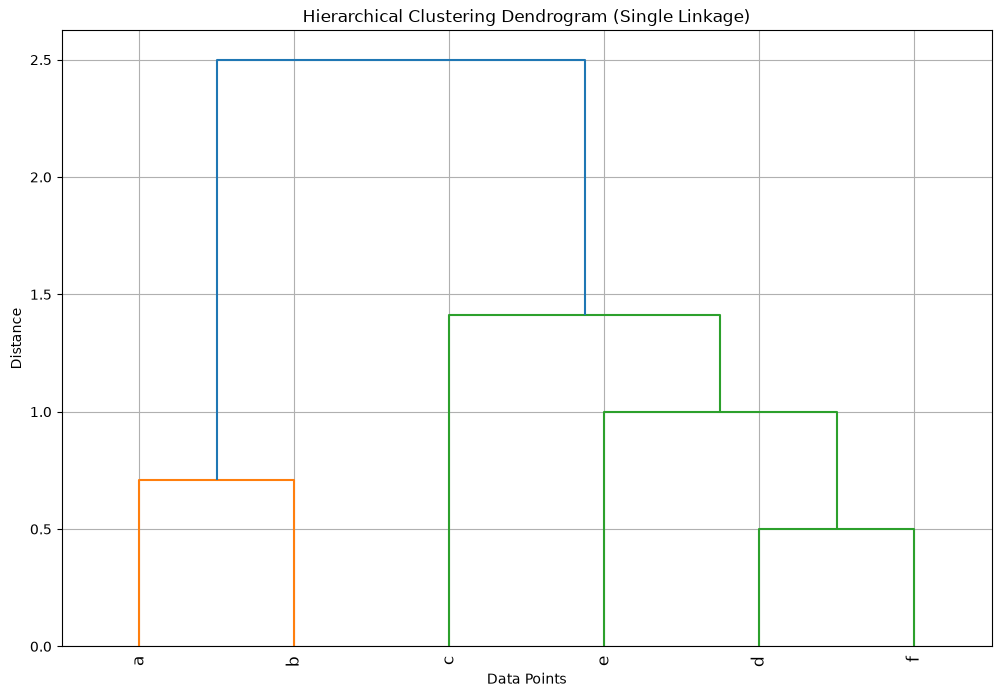

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],   # e
    [3.0, 3.5]   # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
                           columns=['a', 'b', 'c', 'd', 'e', 'f'],
                           index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

import numpy as np, import pandas as pd, dan library dari scipy digunakan untuk mengolah data serta melakukan perhitungan jarak dan hierarchical clustering. Pada bagian data = np.array([ ]), dibuat dataset sederhana yang terdiri dari 6 titik, yaitu a sampai f, dengan masing-masing memiliki dua nilai koordinat. pdist(data, metric='euclidean') digunakan untuk menghitung jarak Euclidean antar setiap titik, kemudian squareform() mengubah hasil jarak tersebut menjadi Distance Matrix yang lebih mudah dibaca dalam bentuk tabel menggunakan Pandas. Selanjutnya, linkage(data, method='single') digunakan untuk melakukan Hierarchical Clustering dengan metode Single Linkage, yaitu penggabungan cluster berdasarkan jarak terdekat antar anggota cluster. Setelah itu, dendrogram() digunakan untuk membuat diagram dendrogram yang menunjukkan proses penggabungan setiap data menjadi beberapa cluster berdasarkan jaraknya. plt.title(), plt.xlabel(), dan plt.ylabel() digunakan untuk memberikan judul serta nama sumbu pada grafik, sedangkan plt.show() digunakan untuk menampilkan hasil dendrogram.

In [3]:
import pandas as pd
df = pd.read_csv("D:\PERKULIAHAN\SEMESTER 5\CERTAN\Week 5\Mall_Customers.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\sara rajagukguk\AppData\Local\Temp\ipykernel_24440\3089778715.py:2: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("D:\PERKULIAHAN\SEMESTER 5\CERTAN\Week 5\Mall_Customers.csv")


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


import pandas as pd digunakan untuk memanggil library Pandas yang digunakan untuk membaca dan mengolah data. pd.read_csv() digunakan untuk membaca file Mall_Customers.csv dari lokasi yang sudah ditentukan, kemudian data tersebut disimpan ke dalam variabel df dalam bentuk DataFrame. Selanjutnya, df.head() digunakan untuk menampilkan 5 baris pertama dari dataset agar kita dapat memastikan bahwa file berhasil dibaca dan melihat gambaran awal data yang akan digunakan.

In [4]:
x = df.iloc[:, [3, 4]].values

x = df.iloc[:, [3, 4]].values digunakan untuk mengambil kolom ke-4 dan ke-5 dari dataset, yaitu Annual Income  dan Spending Score (1-100). df.iloc[:, [3, 4]] memilih kolom berdasarkan nomor indeks, sedangkan .values mengubah data tersebut menjadi bentuk array NumPy. Hasilnya disimpan dalam variabel x dan nantinya digunakan sebagai data input untuk proses clustering, khususnya untuk melihat pengelompokan pelanggan berdasarkan pendapatan dan skor belanja.

In [5]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

from sklearn.preprocessing import StandardScaler digunakan untuk memanggil StandardScaler dari Scikit-learn yang berfungsi untuk melakukan standarisasi data. data_scaler = StandardScaler() membuat objek scaler yang akan digunakan untuk mengubah skala data. Selanjutnya, scaled_data = data_scaler.fit_transform(x) digunakan untuk menghitung rata-rata dan standar deviasi dari data x, kemudian mengubah data sehingga memiliki skala yang lebih seragam dengan rata-rata mendekati 0 dan standar deviasi 1. Terakhir, scaled_data.shape digunakan untuk melihat ukuran atau dimensi data setelah proses scaling, yang pada dataset Mall Customers akan menunjukkan jumlah baris data dan jumlah kolom yang digunakan, yaitu (200, 2).

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

from scipy.cluster.hierarchy import linkage, dendrogram digunakan untuk memanggil fungsi linkage dan dendrogram dari SciPy yang digunakan dalam proses Hierarchical Clustering. clustering = linkage(scaled_data, method="complete", metric="euclidean") digunakan untuk melakukan proses pengelompokan data menggunakan metode Complete Linkage, yaitu penggabungan cluster berdasarkan jarak terjauh antar anggota cluster. metric="euclidean" menunjukkan bahwa jarak antar data dihitung menggunakan Euclidean Distance, sedangkan hasil proses clustering disimpan dalam variabel clustering yang nantinya dapat digunakan untuk membuat dendrogram.

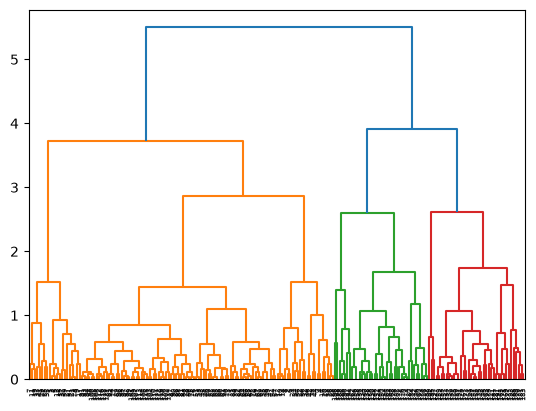

In [7]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

import matplotlib.pyplot as plt digunakan untuk memanggil library Matplotlib yang digunakan untuk membuat dan menampilkan grafik. dendrogram(clustering) digunakan untuk membuat dendrogram berdasarkan hasil proses Hierarchical Clustering yang sebelumnya disimpan dalam variabel clustering, sehingga kita dapat melihat proses penggabungan data menjadi beberapa cluster berdasarkan jaraknya. Kemudian, plt.show() digunakan untuk menampilkan dendrogram tersebut.

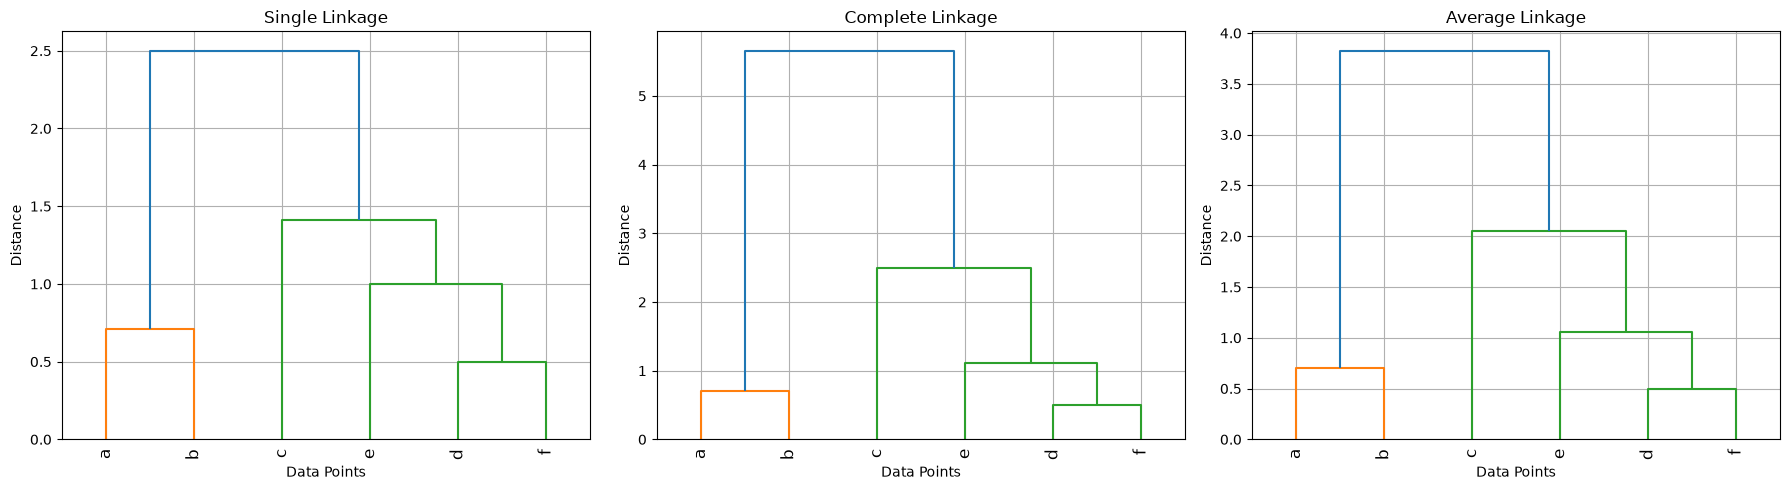

In [21]:
# TUGAS 

# Membuat dendrogram untuk ketiga metode

plt.figure(figsize=(18, 5))

# Single Linkage
plt.subplot(1, 3, 1)
dendrogram(single_linkage, labels=labels, leaf_rotation=90)
plt.title("Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

# Complete Linkage
plt.subplot(1, 3, 2)
dendrogram(complete_linkage, labels=labels, leaf_rotation=90)
plt.title("Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

# Average Linkage
plt.subplot(1, 3, 3)
dendrogram(average_linkage, labels=labels, leaf_rotation=90)
plt.title("Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

plt.tight_layout()
plt.show()

Kode ini digunakan untuk membandingkan hasil dendrogram dari tiga metode Hierarchical Clustering, yaitu Single Linkage, Complete Linkage, dan Average Linkage dalam satu tampilan. plt.figure(figsize=(18, 5)) membuat area grafik dengan ukuran yang cukup lebar. Kemudian plt.subplot(1, 3, 1), plt.subplot(1, 3, 2), dan plt.subplot(1, 3, 3) membagi tampilan menjadi 3 grafik dalam satu baris. dendrogram(single_linkage, labels=labels, leaf_rotation=90), dendrogram(complete_linkage, labels=labels, leaf_rotation=90) , dan dendrogram(average_linkage, labels=labels, leaf_rotation=90) masing-masing menampilkan dendrogram berdasarkan ketiga metode tersebut, sedangkan labels=labels memberikan nama pada setiap data point dan leaf_rotation=90 memutar label agar lebih mudah dibaca. plt.title(), plt.xlabel(), dan plt.ylabel() digunakan untuk memberikan judul serta nama sumbu pada masing-masing grafik, sementara plt.grid(True) menambahkan garis bantu. Terakhir, plt.tight_layout() digunakan untuk mengatur jarak antar grafik agar tidak saling bertumpuk dan plt.show() digunakan untuk menampilkan ketiga dendrogram secara bersamaan, sehingga hasil Single Linkage, Complete Linkage, dan Average Linkage dapat dibandingkan dengan lebih mudah.